### KMeans Clustering — Overview

Unlike RFM scoring (where segments are defined manually through fixed
rules, e.g. "score >= 4 = VIP"), KMeans is an unsupervised algorithm that
discovers customer groups directly from the structure of the data —
no predefined rules required.

### How it works:
1. You choose K (the number of clusters you want)

2. The algorithm places each customer in a multi-dimensional space
(based on their variables: recency, frequency, monetary, etc.)
3. It iteratively finds K centers that minimize the distance between
each customer and the center of their assigned cluster

### Key requirement — standardization:
KMeans relies on distance calculations between customers. Without
rescaling, variables with naturally larger ranges (e.g. monetary:
0–250,000) would dominate the distance calculation over variables with
smaller ranges (e.g. recency: 0–600), making the clustering meaningless.

### StandardScaler rescales every variable to the same scale:
standardized_value = (value - mean) / standard_deviation
After this transformation, all variables have a mean of 0 and a standard
deviation of 1, regardless of their original unit (days, £, count...).

### Data preparation:
- 'Guest' customers are excluded — this single ID aggregates thousands of
anonymous checkouts, producing artificially massive frequency and
monetary values that would distort the clustering

### KMeans works in two steps:
1. Standardize → scaler.fit_transform(df[[...]])
2. Cluster     → KMeans(n_clusters=k).fit(scaled_data)

### Plan for this notebook:
1. KMeans on RFM variables only (recency, frequency, monetary) —
directly comparable to the manual RFM segmentation
2. KMeans enriched with additional variables (e.g. country, product
diversity) to explore richer segmentation patterns

In [61]:
# Libs

from sklearn.preprocessing import StandardScaler
from sqlalchemy import create_engine
import pandas as pd

In [ ]:
# Database connection

engine = create_engine(
    "postgresql+psycopg2://postgres:@localhost:5432/Online Retail II UCI"
)

In [63]:
df_rfm = pd.read_sql("""
    SELECT 
        customer_id, 
        recency,
        frequency,
        monetary
    FROM customer_segments_rfm
    WHERE customer_id != 'Guest';
""", engine)

In [64]:
# standardize the data

scaler = StandardScaler()
df_rfm_scalation = scaler.fit_transform(df_rfm[['recency','frequency','monetary']])

In [70]:
df_rfm_scaled = pd.DataFrame({
    'customer_id': df_rfm['customer_id'],
    'r_scaled':df_rfm_scalation[:,0],
    'f_scaled':df_rfm_scalation[:,1],
    'm_scaled':df_rfm_scalation[:,2]
})

In [69]:
from sklearn.cluster import KMeans

inertias = []
for k in range(1,11):
    model = KMeans(n_clusters=k)
    model.fit(df_rfm_scaled[['r_scaled', 'f_scaled', 'm_scaled']])
    inertias.append(model.inertia_)

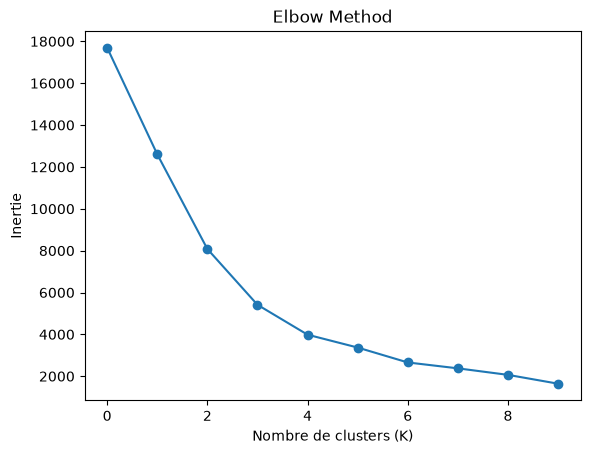

In [68]:
import matplotlib.pyplot as plt

plt.plot(inertias, marker='o')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Inertie')
plt.title('Elbow Method')
plt.show()

.fit(X)           → trains the model on X
                    does not return anything useful

.predict(X)       → you must call .predµict() separately afterwards assigns each row to a cluster
                    requires the model to have already been trained (fit must be run first)

.fit_predict(X)   → does both in a single step
                    trains the model AND returns the clusters immediately

.fit() + .predict() → when training on a dataset and applying on another

.fit_predict(X) → when doing both on the same dataset

In [71]:
model = KMeans(n_clusters=4)
clusters = model.fit_predict(df_rfm_scaled[['r_scaled', 'f_scaled', 'm_scaled']])

df_segmentation = pd.DataFrame({
    'customer_id': df_rfm['customer_id'],
    'recency':df_rfm['recency'],
    'frequency':df_rfm['frequency'],
    'monetary':df_rfm['monetary'],
    'cluster_id':clusters
})

print(df_segmentation.head())

  customer_id  recency  frequency  monetary  cluster_id
0       17592      738          2      0.00           1
1       12636      738          1     18.00           1
2       17641      738          1     -7.95           1
3       17087      737          1    221.53           1
4       17818      737          1    124.73           1


To understand what KMeans found, you need to look at the means for each cluster

In [72]:
df_segmentation.groupby('cluster_id')[['recency', 'frequency', 'monetary']].mean()

,recency,frequency,monetary
cluster_id,,,
0,65.018658,8.733351,2965.496989
1,464.033500,2.590000,768.101400
2,36.894737,135.789474,102853.674474
3,0.500000,157.000000,766873.715000


In [73]:
df_segmentation.groupby('cluster_id')['customer_id'].count()

cluster_id
0    3859
1    2000
2      38
3       2
Name: customer_id, dtype: int64

In [74]:
labels = {
    0: 'Regular',
    1: 'To Reactivate',
    2: 'Wholesaler',
    3: 'Key Account'  
}

df_segmentation['cluster_id'] = df_segmentation['cluster_id'].map(labels)
print(df_segmentation)

     customer_id  recency  frequency  monetary     cluster_id
0          17592      738          2      0.00  To Reactivate
1          12636      738          1     18.00  To Reactivate
2          17641      738          1     -7.95  To Reactivate
3          17087      737          1    221.53  To Reactivate
4          17818      737          1    124.73  To Reactivate
...          ...      ...        ...       ...            ...
5894       14730        0          8   1903.24        Regular
5895       17144        0          2   1133.69        Regular
5896       16322        0          2    319.20        Regular
5897       13471        0          4   2676.61        Regular
5898       13081        0         44  59109.02        Regular

[5899 rows x 5 columns]


In [75]:
df_segmentation.to_sql(
    name='segmentation_rfm_kmeans',
    con=engine,
    if_exists='append',
    index=False
)

899